Hello Deena, welcome to my notebook showcasing my automl library. If you are interested you can look at the diagram in the chat.

The goal of the program is that the user can easily use advanced predifined or custom hypertuning and feature selection methods on their dataset.

The user needs to supply the target column as a string, the dataset as a df, as well as either choose from the predifined hypertuning and feature selection methods or make their own which uphold a interface.

The run_automl method first runs the feature selection function if defined. then the hypertuning method if defined.



In [1]:

import sys
import pandas as pd
from pathlib import Path

#the import process will be different if made like a true library
code = Path.cwd()/'code'
sys.path.append(str(code))
from automl.automl import SimpleAutoML
from Loss import mae, mape
from feature_selection.forward import ForwardFeatureSelector
from feature_selection.backwards import BackwardFeatureSelector  
from hyper_tuning import GridSearchTuner, RandomSearchTuner, LineSearchTuner  
pd.options.display.max_columns = None



In [2]:

data_path='cleaned_data_harsh.csv'

df=pd.read_csv(data_path)
df=df.sample(frac=0.05, random_state=42) #5 percent of the data

df_clean=df.drop(columns=['dato'])
print(f"data shape {df_clean.shape}")

automl=SimpleAutoML()


data shape (76117, 21)
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Registered model: linear_regression
Registered model: xgboost


In [3]:
# a simple run through with no feature selection and no hyperparameter tuning

results = automl.run_automl( df=df_clean,
    target_col='Købesum', # target column
    feature_selection_fn=None, # how you specify no feature selection
    models_to_run=['linear_regression', 'xgboost'], # models we would like to include if we dont supply this then all valid models are chosen
    hypertuning_fn=None, # how you specify no hyperparameter tuning
    loss_fn=mae(), # loss function to use
    n_splits=5, # number of splits for cross-validation i use scikitlearn time series split
    test_split=0.1) # percentage of the data to use for testing

Data split - Train: 68505, Test: 7612
Training 2 models: ['linear_regression', 'xgboost']

Training linear_regression
  Using default parameters for linear_regression
linear_regression - Test mae: 1196648.85 (Features: 20)

Training xgboost
  Using default parameters for xgboost
xgboost - Test mae: 916447.56 (Features: 20)

AUTOML RESULTS
linear_regression: Test mae: 1,196,648.85
xgboost: Test mae: 916,447.56

Best Model: xgboost
Best Test mae: 916,447.56


In [4]:

save_path = automl.save_model('saved_models/Deenaexample1') # how we can save the model and specification like the scalar and columns we used

Model package saved to: saved_models/Deenaexample1.pkl
Model weights saved to: saved_models/Deenaexample1_xgboost.json


In [5]:
# example with feature selection
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=ForwardFeatureSelector,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=None,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running feature selection for xgboost
Starting forward feature selection with 20 available features
Added feature: mean_of_5_neighbors_pris, CV Score: 1075762.0250, Selected: 1
Added feature: pris_pr_m2_mean_365D_by, CV Score: 1027584.5375, Selected: 2
Added feature: age, CV Score: 999343.1250, Selected: 3
Added feature: m2, CV Score: 967741.4000, Selected: 4
Added feature: std_of_5_neighbors_pris_pr_m2, CV Score: 954004.0000, Selected: 5
Added feature: btype_Villa, CV Score: 942266.4750, Selected: 6
Added feature: btype_Fritidshus, CV Score: 935464.4250, Selected: 7
Added feature: omr_de_Hovedstaden__K_benhavn, CV Score: 930185.6000, Selected: 8
Added feature: date_ordinal, CV Score: 923547.8750, Selected: 9
Added feature: btype_R_kkehus, CV Score: 921699.9375, Selected: 10
Added feature: omr_de_Nordsj_lland, CV Score: 919865.1375, Selected: 11
Added feature: omr_de_Sydjylland

In [6]:
# another type of feature selection, cool huh? 

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=BackwardFeatureSelector,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=None,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running feature selection for xgboost
Starting backward feature selection with 20 features
Initial CV Score: 919094.4500
Dropped feature: btype_Landejendom, CV Score: 917700.2875, Remaining: 19
Dropped feature: omr_de_Bornholm, CV Score: 917190.6250, Remaining: 18
No improvement found
  Features after selection for xgboost: 18
  Using default parameters for xgboost
xgboost - Test mae: 919732.12 (Features: 18)

Training linear_regression
  Running feature selection for linear_regression
Starting backward feature selection with 20 features
Initial CV Score: 1188334.7955
Dropped feature: btype_Villa, CV Score: 1184978.0877, Remaining: 19
Dropped feature: age, CV Score: 1180672.8910, Remaining: 18
Dropped feature: btype_Fritidshus, CV Score: 1178108.3858, Remaining: 17
Dropped feature: btype_R_kkehus, CV Score: 1175549.2472, Remaining: 16
Dropped feature: V_r_, CV Score: 1173412.57

In [7]:
# hypertuning

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=RandomSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 10 random parameter combinations
Best parameters: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 9}
Best CV score: 917946.0500
  Best params for xgboost: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 9}
xgboost - Test mae: 906513.25 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 10 random parameter combinations
Best parameters: {'model_type': 'ridge', 'alpha': 10.0}
Best CV score: 1188310.8808
  Best params for linear_regression: {'model_type': 'ridge', 'alpha': 10.0}
linear_regression - Test mae: 1196639.66 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 906,513.25
linear_regression: Test mae: 1,196,639.66

Best Model: xgboost
Best Test mae: 906,513.25


In [8]:
#not really made in a cool way, should be refactored, but it is possible to alter the parameters of the predifined functions.

def tuner( estimator, loss_fn, param_grid, cv, n_jobs, verbose,):
    return RandomSearchTuner(
        estimator=estimator,
        loss_fn=loss_fn,
        param_grid=param_grid, 
        cv=cv,
        n_iter=25,
        verbose=verbose # here we can directly change the number of iterations for the random search tuning
    )

results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=tuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 25 random parameter combinations
Best parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6}
Best CV score: 916261.1375
  Best params for xgboost: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 6}
xgboost - Test mae: 919365.50 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 25 random parameter combinations
Best parameters: {'model_type': 'ridge', 'alpha': 10.0}
Best CV score: 1188310.8808
  Best params for linear_regression: {'model_type': 'ridge', 'alpha': 10.0}
linear_regression - Test mae: 1196639.66 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 919,365.50
linear_regression: Test mae: 1,196,639.66

Best Model: xgboost
Best Test mae: 919,365.50


In [9]:
# two more examples with hypertuning
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=GridSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1)

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Testing 12 parameter combinations
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV score: 981204.4125
  Best params for xgboost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
xgboost - Test mae: 998024.81 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Testing 6 parameter combinations
Best parameters: {'alpha': 0.1, 'model_type': 'linear'}
Best CV score: 1188334.7955
  Best params for linear_regression: {'alpha': 0.1, 'model_type': 'linear'}
linear_regression - Test mae: 1196648.85 (Features: 20)

AUTOML RESULTS
xgboost: Test mae: 998,024.81
linear_regression: Test mae: 1,196,648.85

Best Model: xgboost
Best Test mae: 998,024.81


In [ ]:
#via the parameter param_amount we can specifiy how big of a parameter space we want to have
results = automl.run_automl( df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None,
    models_to_run=[ 'xgboost','linear_regression',],
    hypertuning_fn=LineSearchTuner,
    loss_fn=mae(),
    n_splits=5,
    test_split=0.1,
    param_amount='big')

Data split - Train: 68505, Test: 7612
Training 2 models: ['xgboost', 'linear_regression']

Training xgboost
  Running hyperparameter tuning for xgboost
Starting Line Search with initial params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 0.8}

 Pass 1/2
  New best for 'n_estimators': 750 -> Score: 960064.3000
  New best for 'learning_rate': 0.1 -> Score: 918657.4625
  New best for 'colsample_bytree': 1.0 -> Score: 917953.4500

 Pass 2/2
Stopping early, no improvement in a full pass.

Best parameters found: {'n_estimators': 750, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best CV score: 917953.4500
  Best params for xgboost: {'n_estimators': 750, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 0.8, 'colsample_bytree': 1.0}
xgboost - Test mae: 922632.31 (Features: 20)

Training linear_regression
  Running hyperparameter tuning for linear_regression
Starting Line Search with initial params: {'mo

In [11]:
data_path='cleaned_data_harsh.csv'

df=pd.read_csv(data_path)

df_clean=df.drop(columns=['dato'])
print(f"data shape {df_clean.shape}")

automl=SimpleAutoML()


data shape (1522344, 21)
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Registered model: linear_regression
Registered model: xgboost


In [2]:
results = automl.run_automl( 
    df=df_clean,
    target_col='Købesum',
    feature_selection_fn=None, 
    hypertuning_fn=LineSearchTuner, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.02, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

NameError: name 'automl' is not defined

In [3]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harsh.csv')
df_clean = df.drop(columns=['dato'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

# simple split - last 2% for testing
test_size = int(0.02 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('Købesum', axis=1)
y_train = train_data['Købesum']
X_test = test_data.drop('Købesum', axis=1)
y_test = test_data['Købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05, 
    max_depth=9,
    random_state=42
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()

train: 1,491,898, test: 30,446


KeyboardInterrupt: 

In [4]:

import numpy as np

df = pd.read_csv('cleaned_data_harshertesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df[df['btype'] == 'Ejerlejlighed']
df = df.drop(columns=['dato', 'btype'])
print(f"data shape {df.head}")

automl=SimpleAutoML()

for col in df.select_dtypes(include=[np.number]).columns:
        df = df[~np.isinf(df[col])]

results = automl.run_automl( 
    df=df,
    target_col='købesum',
    feature_selection_fn=None, 
    hypertuning_fn=RandomSearchTuner, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.10, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

data shape <bound method NDFrame.head of           index  købesum  prev_købesum  price_change  price_change_pct  Vær.  \
406362        6  2115000           NaN           NaN               NaN     4   
143062        0   296270           NaN           NaN               NaN     3   
280216       27   210000           NaN           NaN               NaN     2   
156932       30   640000           NaN           NaN               NaN     3   
216377       33   325000           NaN           NaN               NaN     3   
...         ...      ...           ...           ...               ...   ...   
53874   2352544  3550000     2865000.0      685000.0         23.909250     2   
347877  2352623  1073000      675000.0      398000.0         58.962963     3   
220109  2352676  2225000     1750000.0      475000.0         27.142857     3   
348356  2352620  1675000     1280000.0      395000.0         30.859375     3   
347798  2352621  2498000     2273000.0      225000.0          9.898812     2   

In [2]:
import numpy as np

df = pd.read_csv('cleaned_data_harshertesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df.drop(columns=['dato', 'price_change', 'price_change_pct'])
df = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

automl=SimpleAutoML()

for col in df.select_dtypes(include=[np.number]).columns:
        df = df[~np.isinf(df[col])]

results = automl.run_automl( 
    df=df,
    target_col='købesum',
    feature_selection_fn=None, 
    hypertuning_fn=LineSearchTuner, 
    loss_fn=mape(),
    n_splits=5,
    test_split=0.20, #approximately 6 months into the future 35k houses. 
    param_amount='custom' 
)

Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/lightgbm.py: No module named 'lightgbm'
Failed to load model from /Users/victor/School/bachelor 2/bachelor/automltrainer/code/models/linear_regression.py: Can't instantiate abstract class LinearRegressionConfig without an implementation for abstract method 'save_model'
Registered model: xgboost
Data split - Train: 1882191, Test: 470548
Training 1 models: ['xgboost']

Training xgboost
  Running hyperparameter tuning for xgboost
Starting Line Search with initial params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3}

 Pass 1/2
  New best for 'n_estimators': 600 -> Score: 0.4696
  New best for 'learning_rate': 0.1 -> Score: 0.4643
  New best for 'max_depth': 6 -> Score: 0.4634

 Pass 2/2
  New best for 'n_estimators': 100 -> Score: 0.4593
  New best for 'learning_rate': 0.05 -> Score: 0.4586
  New best for 'max_depth': 9 -> Score: 0.4579

Best parameters found: {'n_estimators': 100, 

train: 327,972, test: 81,993
overall mape: 3.8%


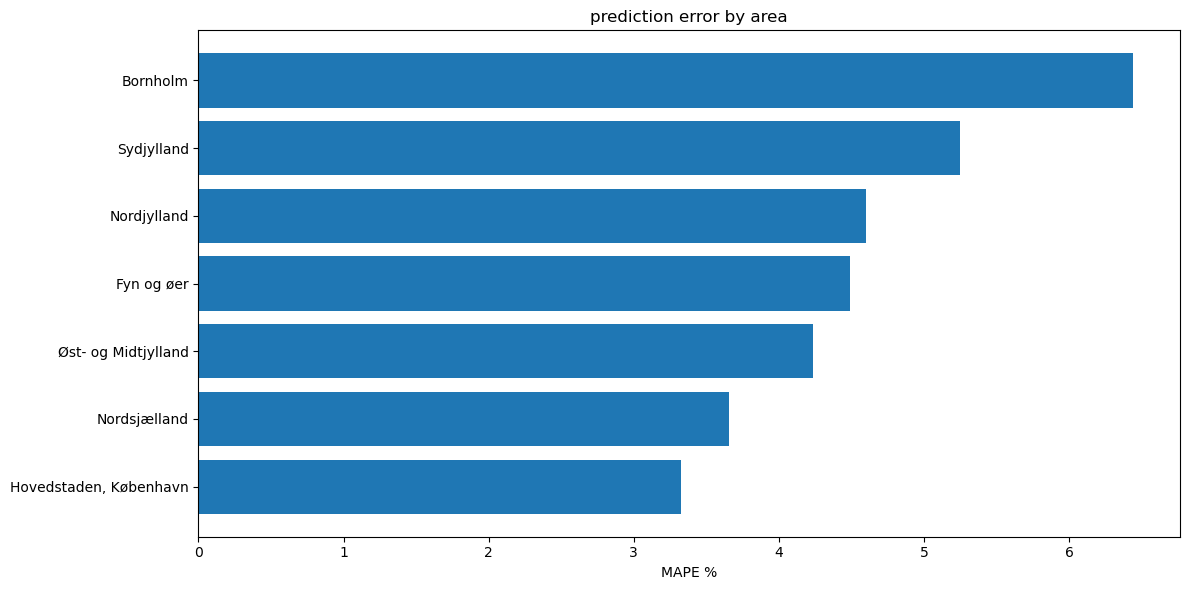


By area:
                  area     mape  count
Hovedstaden, København 3.325671  41939
          Nordsjælland 3.654350   5313
   Øst- og Midtjylland 4.232340  13418
            Fyn og øer 4.491753   3567
           Nordjylland 4.602059   5675
            Sydjylland 5.246625   5552
              Bornholm 6.441387     50


In [15]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df_clean = df.drop(columns=['dato','pris_pr_m2_temp'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05, 
    max_depth=9,
    random_state=42
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(12, 6))
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('prediction error by area')
plt.tight_layout()
plt.show()


print(f"\nBy area:")
print(results_df.to_string(index=False))

In [14]:
df.sample(20)

,Unnamed: 0,dato,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,pris_pr_m2_temp,pris_pr_m2_prev,pris_pr_m2_mean_365D_by,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_365D_by_prev,days_since_last_sale,num_neighbors_used_5,mean_of_5_neighbors_pris_pr_m2,num_neighbors_used_15,mean_of_15_neighbors_pris_pr_m2,num_neighbors_used_30,mean_of_30_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_by,historical_premium_vs_by_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,mean_of_5_neighbors_pris
287855,287855,2020-09-10 22:00:00+00:00,1400000,NaN,NaN,NaN,4,82.0,17073.170732,NaN,16885.652210,16885.652210,NaN,NaN,NaN,5,14160.042731,6,14235.933045,6,14235.933045,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,1.167347e+06,1.161124e+06
343935,343935,2003-04-30 22:00:00+00:00,631254,NaN,NaN,NaN,3,102.0,6188.764706,NaN,9716.485297,9716.485297,NaN,NaN,NaN,1,14833.333333,1,14833.333333,1,14833.333333,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,1.513000e+06,1.513000e+06
174211,174211,2018-11-01 23:00:00+00:00,1975000,1450000.0,525000.0,36.206897,2,60.0,32916.666667,24166.666667,27446.063116,27446.063116,19400.552288,19400.552288,1005.0,5,28959.523810,9,28617.724868,9,28617.724868,4766.114379,24.566901,4766.114379,24.566901,0,0,1,0,0,0,0,1.717063e+06,1.737571e+06
15053,15053,2017-09-30 22:00:00+00:00,1495000,999000.0,496000.0,49.649650,2,48.0,31145.833333,20812.500000,25349.528767,25349.528767,18841.975951,18841.975951,792.0,5,25602.781313,9,25781.977310,9,25781.977310,1970.524049,10.458160,1970.524049,10.458160,0,0,1,0,0,0,0,1.237535e+06,1.228934e+06
274726,274726,2021-12-06 23:00:00+00:00,490000,NaN,NaN,NaN,1,39.0,12564.102564,NaN,18576.305171,18576.305171,NaN,NaN,NaN,5,11310.219250,9,11147.137975,9,11147.137975,NaN,NaN,NaN,NaN,0,1,0,0,0,0,0,4.347384e+05,4.410986e+05
409009,409009,2022-07-10 22:00:00+00:00,4050000,NaN,NaN,NaN,3,80.0,50625.000000,NaN,41579.131205,41579.131205,NaN,NaN,NaN,5,47549.193877,15,44199.402713,30,43117.652041,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,3.449412e+06,3.803936e+06
337710,337710,1998-02-14 23:00:00+00:00,694600,NaN,NaN,NaN,2,72.0,9647.222222,NaN,10731.001264,10731.001264,NaN,NaN,NaN,4,11712.406430,4,11712.406430,4,11712.406430,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,8.432933e+05,8.432933e+05
362596,362596,2016-11-15 23:00:00+00:00,925000,810000.0,115000.0,14.197531,3,76.0,12171.052632,10657.894737,11086.596382,11086.596382,12191.919625,12191.919625,1629.0,5,10079.515015,7,10234.981628,7,10234.981628,-1534.024888,-12.582308,-1534.024888,-12.582308,0,0,0,0,0,0,1,7.778586e+05,7.660431e+05
309260,309260,1996-10-09 22:00:00+00:00,215000,NaN,NaN,NaN,2,43.0,5000.000000,NaN,6853.308979,6853.308979,NaN,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN
2378,2378,2010-09-30 22:00:00+00:00,1485000,NaN,NaN,NaN,3,59.0,25169.491525,NaN,23824.181403,23824.181403,NaN,NaN,NaN,5,23087.340382,5,23087.340382,5,23087.340382,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,1.362153e+06,1.362153e+06


train: 1,882,192, test: 470,547
overall mape: 38.1%

By building type:
        btype      mape  count
Ejerlejlighed 16.472035  83879

By building type:
        btype      mape  count
Ejerlejlighed 16.472035  83879
   Fritidshus 44.548495  65857

By building type:
        btype      mape  count
Ejerlejlighed 16.472035  83879
   Fritidshus 44.548495  65857
  Landejendom 79.406183  16489

By building type:
        btype      mape  count
Ejerlejlighed 16.472035  83879
     Rækkehus 22.936421  39679
   Fritidshus 44.548495  65857
  Landejendom 79.406183  16489

By building type:
        btype      mape  count
Ejerlejlighed 16.472035  83879
     Rækkehus 22.936421  39679
        Villa 43.091958 264643
   Fritidshus 44.548495  65857
  Landejendom 79.406183  16489


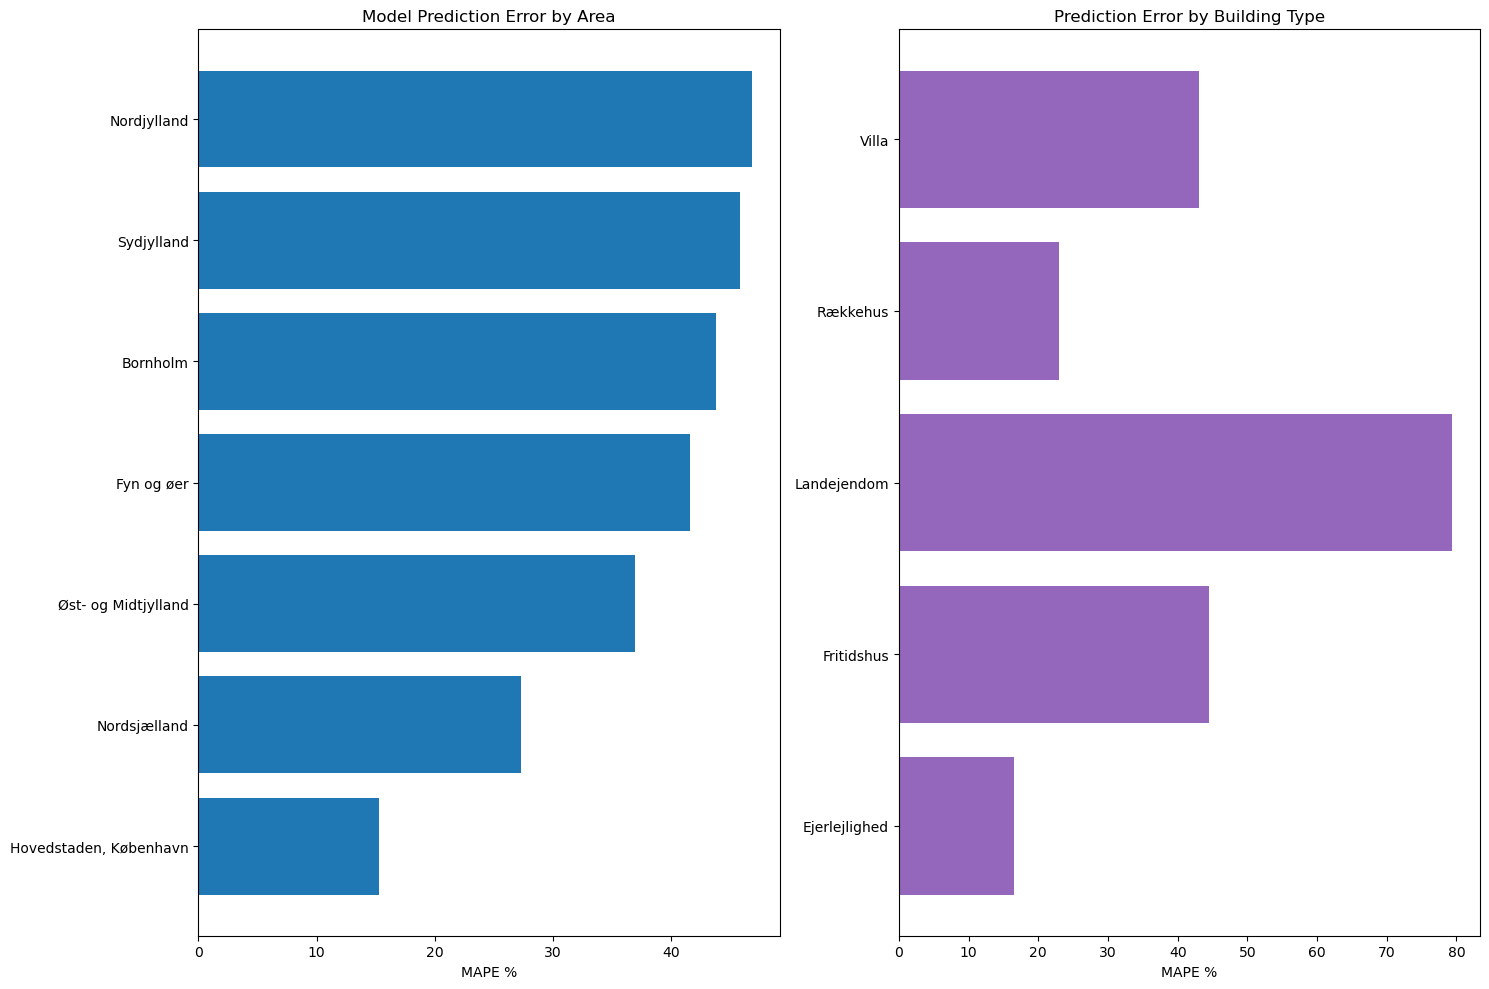


By area:
                  area      mape  count
Hovedstaden, København 15.317575  60462
          Nordsjælland 27.325596  32101
   Øst- og Midtjylland 36.960283  77494
            Fyn og øer 41.566508  42296
              Bornholm 43.839112   5746
            Sydjylland 45.842880 111927
           Nordjylland 46.838562  54051


In [4]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df.drop(columns=['dato', 'price_change', 'price_change_pct'])
df_clean = pd.get_dummies(df, columns=['btype'], dtype=int,prefix_sep='.')

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1, 
    max_depth=6,
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Model Prediction Error by Area')

btype_cols = [col for col in test_data.columns if 'btype.' in col]

if btype_cols:  # if we have building type columns
    btype_results = []

for col in btype_cols:
    btype_data = test_data[test_data[col] == 1]
    if len(btype_data) > 5:
        btype_name = col.replace('btype.', '')
        btype_actual = y_test[test_data[col] == 1]
        btype_preds = preds[test_data[col] == 1]
        btype_mape = mape(btype_actual, btype_preds)
        btype_results.append([btype_name, btype_mape, len(btype_data)])
    
    btype_results_df = pd.DataFrame(btype_results, columns=['btype', 'mape', 'count'])
    btype_results_df = btype_results_df.sort_values('mape')
    
    # Plot by building type
    plt.subplot(1, 2, 2)
    plt.barh(btype_results_df['btype'], btype_results_df['mape'])
    plt.xlabel('MAPE %')
    plt.title('Prediction Error by Building Type')
    
    print(f"\nBy building type:")
    print(btype_results_df.to_string(index=False))

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [8]:
df.head(10)

,index,købesum,prev_købesum,price_change,price_change_pct,Vær.,m2,btype,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted,mean_of_5_neighbors_pris
1916951,18,660000,NaN,NaN,NaN,4,159.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1474057,5,1100000,NaN,NaN,NaN,4,108.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1564890,9,450000,NaN,NaN,NaN,4,101.0,Fritidshus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1461534,20,350000,NaN,NaN,NaN,4,66.0,Fritidshus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1035763,1,250000,NaN,NaN,NaN,5,65.0,Fritidshus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1979799,10,895000,NaN,NaN,NaN,8,180.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1188337,3,215000,NaN,NaN,NaN,4,79.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN
406362,6,2115000,NaN,NaN,NaN,4,122.0,Ejerlejlighed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
497783,4,1355000,NaN,NaN,NaN,5,152.0,Rækkehus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1549568,21,1050000,NaN,NaN,NaN,9,260.0,Villa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN


train: 1,882,191, test: 470,547
overall mape: 11.1%


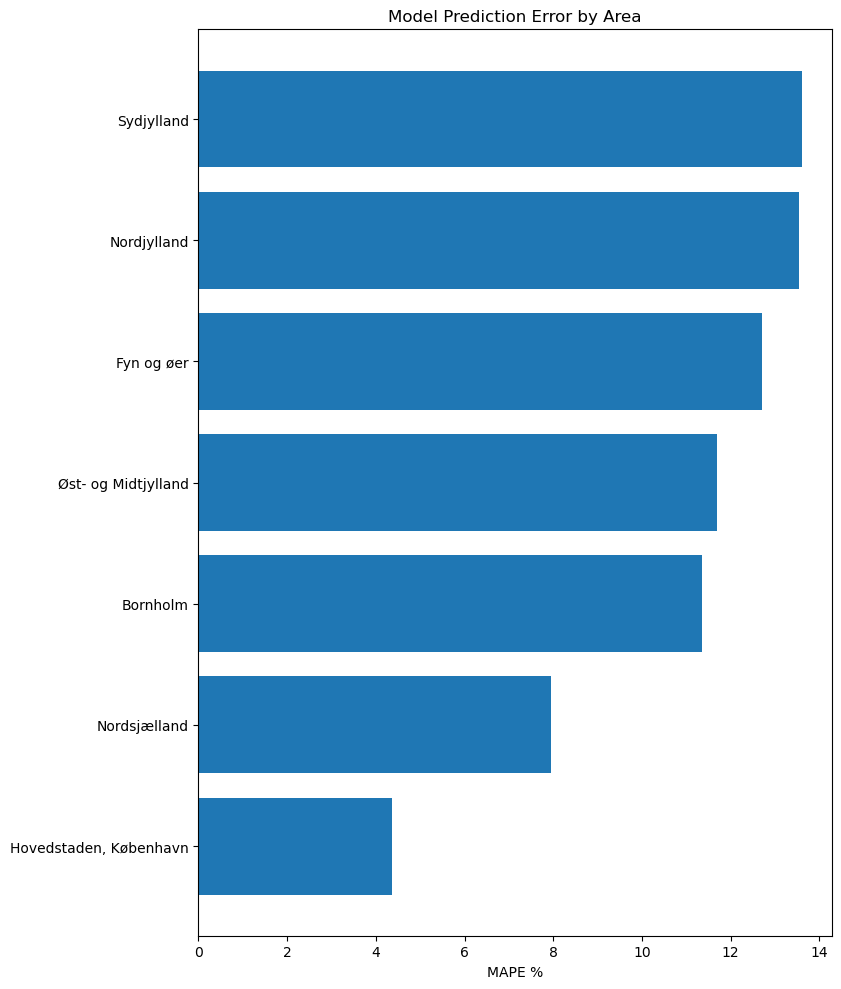


By area:
                  area      mape  count
Hovedstaden, København  4.374491  60461
          Nordsjælland  7.958416  32101
              Bornholm 11.350431   5746
   Øst- og Midtjylland 11.695091  77494
            Fyn og øer 12.712329  42297
           Nordjylland 13.538534  54051
            Sydjylland 13.597618 111927


In [10]:
# testing xgboost with best params on holdout data by area
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
df = pd.read_csv('cleaned_data_harshertesttest.csv')
df['dato'] = pd.to_datetime(df['dato'])
df = df.sort_values('dato')
df = df[df['btype'] == 'Ejerlejlighed']
df = df.drop(columns=['dato', 'price_change', 'price_change_pct', 'btype'])

def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

for col in df_clean.select_dtypes(include=['float', 'float64']).columns:
    df_clean = df_clean[~np.isinf(df_clean[col])]

# simple split - last 2% for testing
test_size = int(0.2 * len(df_clean))
train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print(f"train: {len(train_data):,}, test: {len(test_data):,}")

# prep the data
X_train = train_data.drop('købesum', axis=1)
y_train = train_data['købesum']
X_test = test_data.drop('købesum', axis=1)
y_test = test_data['købesum']

# scale it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train with best params
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03, 
    max_depth=9,
)

model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)

print(f"overall mape: {mape(y_test, preds):.1f}%")

# by area
area_cols = [col for col in test_data.columns if 'område_' in col]

# quick plot
results = []
for col in area_cols:
    area_data = test_data[test_data[col] == 1]
    if len(area_data) > 5:
        area_name = col.replace('område_', '')
        area_actual = y_test[test_data[col] == 1]
        area_preds = preds[test_data[col] == 1]
        area_mape = mape(area_actual, area_preds)
        results.append([area_name, area_mape, len(area_data)])

results_df = pd.DataFrame(results, columns=['area', 'mape', 'count'])
results_df = results_df.sort_values('mape')

plt.figure(figsize=(15, 10))

# Plot by area
plt.subplot(1, 2, 1)
plt.barh(results_df['area'], results_df['mape'])
plt.xlabel('MAPE %')
plt.title('Model Prediction Error by Area')

plt.tight_layout()
plt.show()

print(f"\nBy area:")
print(results_df.to_string(index=False))

In [11]:
df.sample(10)

,index,købesum,prev_købesum,Vær.,m2,pris_pr_m2_mean_365D_postnummer,pris_pr_m2_mean_365D_postnummer_btype,pris_pr_m2_prev,pris_pr_m2_mean_postummer_prev,pris_pr_m2_mean_postnummer_btype_prev,days_since_last_sale,num_of_5_neighbors,mean_of_5_neighbors_pris_pr_m2,num_of_5_samebtype_neighbors,mean_of_5_samebtype_neighbors_pris_pr_m2,num_of_15_neighbors,mean_of_15_neighbors_pris_pr_m2,num_of_15_samebtype_neighbors,mean_of_15_samebtype_neighbors_pris_pr_m2,num_of_30_neighbors,mean_of_30_neighbors_pris_pr_m2,num_of_30_samebtype_neighbors,mean_of_30_samebtype_neighbors_pris_pr_m2,historical_premium_vs_postnummer,historical_premium_vs_postnummer_pct,historical_premium_vs_postnummer_btype,historical_premium_vs_postnummer_btype_pct,område_Bornholm,område_Fyn og øer,"område_Hovedstaden, København",område_Nordjylland,område_Nordsjælland,område_Sydjylland,område_Øst- og Midtjylland,mean_of_30_neighbors_pris,postnummer_pris_estimate,postnummer_pris_premium_adjusted,postnummer_btype_pris_estimate,postnummer_btype_pris_premium_adjusted,mean_of_5_neighbors_pris
344184,1937052,1770000,1600000.0,3,78.0,23490.403337,21196.503981,20512.820513,19743.075703,19625.495107,1835.0,5.0,25667.986338,5.0,25667.986338,7.0,24532.818572,6.0,25437.607662,7.0,24532.818572,6.0,25437.607662,769.744810,3.898809,887.325406,4.521289,0,0,0,0,0,0,1,1.913560e+06,1.832251e+06,1.903687e+06,1.653327e+06,1.728079e+06,2.002103e+06
235465,814930,995000,445000.0,2,62.0,12143.168505,15136.225937,7177.419355,5278.549088,6835.989553,4505.0,5.0,15816.129032,5.0,15816.129032,6.0,15767.826825,6.0,15767.826825,6.0,15767.826825,6.0,15767.826825,1898.870267,35.973337,341.429802,4.994592,0,0,0,0,0,0,0,9.776053e+05,7.528764e+05,1.023711e+06,9.384460e+05,9.853176e+05,9.806000e+05
4198,659352,665480,NaN,1,35.0,14359.831473,14899.104480,NaN,NaN,NaN,NaN,5.0,13675.567012,5.0,13675.567012,9.0,13608.296423,9.0,13608.296423,9.0,13608.296423,9.0,13608.296423,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,4.762904e+05,5.025941e+05,NaN,5.214687e+05,NaN,4.786448e+05
364324,913893,175000,148000.0,1,45.0,6248.758808,6006.980636,3288.888889,4842.302479,4024.140523,2721.0,5.0,5445.569778,5.0,5445.569778,9.0,5580.344731,9.0,5580.344731,9.0,5580.344731,9.0,5580.344731,-1553.413590,-32.080061,-735.251634,-18.271023,0,0,0,0,0,0,1,2.511155e+05,2.811941e+05,1.909869e+05,2.703141e+05,2.209250e+05,2.450506e+05
414226,1758399,3639181,NaN,4,112.0,25790.005915,26166.359163,NaN,NaN,NaN,NaN,5.0,14069.590296,5.0,27106.851422,15.0,21850.895071,15.0,27737.032561,30.0,25848.951790,30.0,28718.607771,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,2.895083e+06,2.888481e+06,NaN,2.930632e+06,NaN,1.575794e+06
48359,2246233,2980000,1595000.0,3,68.0,48525.068438,48525.068438,23455.882353,24197.697474,24251.507499,3586.0,5.0,44225.150757,5.0,44225.150757,10.0,47455.271440,10.0,47455.271440,10.0,47455.271440,10.0,47455.271440,-741.815121,-3.065643,-795.625146,-3.280724,0,0,1,0,0,0,0,3.226958e+06,3.299705e+06,3.198547e+06,3.299705e+06,3.191450e+06,3.007310e+06
137085,2242271,2595000,1450000.0,2,61.0,34295.617583,34762.253597,23770.491803,23520.427402,21949.268784,3416.0,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,4.0,38080.230650,250.064402,1.063180,1821.223019,8.297420,0,0,1,0,0,0,0,2.322894e+06,2.092033e+06,2.114275e+06,2.120497e+06,2.296444e+06,2.322894e+06
71204,699747,1315000,600000.0,2,60.0,17493.259032,17493.259032,10000.000000,18204.950609,18204.950609,317.0,5.0,15851.636119,5.0,15851.636119,12.0,17922.737351,12.0,17922.737351,12.0,17922.737351,12.0,17922.737351,-8204.950609,-45.069887,-8204.950609,-45.069887,0,0,1,0,0,0,0,1.075364e+06,1.049596e+06,5.765440e+05,1.049596e+06,5.765440e+05,9.510982e+05
148485,1934453,2925000,2700000.0,4,86.0,31051.979510,29918.736400,31395.348837,27776.545854,27304.356264,771.0,5.0,31083.375540,5.0,31083.375540,10.0,32690.912576,10.0,32690.912576,10.0,32690.912576,10.0,32690.912576,3618.802984,13.028269,4090.992573,14.982930,0,0,1,0,0,0,0,2.811418e+06,2.670470e+06,3.018386e+06,2.57301